In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import scqubits
from functools import partial
import qutip


# 1. Sweep temp, get T1 of f->e, e->f, e->g, g->e

In [6]:
hbar = 1/(2*np.pi)
kB = 8.617333262e-5  # eV K−1
hbar_in_eVs = 6.5821e-16  # eV s

def diel_spectral_density(omega, EC,temp_in_mK = 20 ,tangent_ref = 1e-5):
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    coth_arg = beta * hbar_in_eVs * np.abs(omega) / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val = np.where(omega < 0, 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) - 1) , 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) + 1) )

    omega_ref = 2*np.pi *6 # GHz
    epsilon = 0.15
    Q_cap = 1/(  2* tangent_ref * np.abs(omega/omega_ref)**epsilon ) 

    return_val *= hbar * np.abs(omega)**2   / (4 * EC * Q_cap)  # GHZ^2/GHZ = GHZ
    return return_val

def one_over_f_spectral_density(omega, EL,one_over_f_flux_noise_amplitude ):
    return_val = 2 * np.pi # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val /= omega  # GHz
    return np.abs(return_val)


class gfIFQ:
    def __init__(self,
                 EJ,
                 EC,
                 EL,
                 flux=0, truncated_dim=5) -> None:
        self.fluxonium = scqubits.Fluxonium(EJ=EJ,
                                            EC=EC,
                                            EL=EL,
                                            flux=flux, cutoff=110,
                                            truncated_dim=truncated_dim)
        self.truncated_dim = truncated_dim
        self.evals = self.fluxonium.eigenvals(evals_count=truncated_dim)
        self.diag_hamiltonian = qutip.Qobj(2 * np.pi * np.diag(self.evals))
        self.phi_tabel = self.fluxonium.matrixelement_table(
            'phi_operator', evals_count=truncated_dim)
        
    def get_c_ops(self,
                  temp_in_mK,
                  loss_tangent_ref,
                  one_over_f_flux_noise_amplitude) -> None:
        # array element [i,j] means transition rate from j to i
        dielectric_T1_array = np.full(
            (self.truncated_dim, self.truncated_dim), np.inf)
        one_over_f_T1_array = np.full(
            (self.truncated_dim, self.truncated_dim), np.inf)
        EL = self.fluxonium.EL
        EC = self.fluxonium.EC
        # T1
        for i in range(self.truncated_dim):
            for j in range(self.truncated_dim):
                if i == j:
                    continue
                freq = (self.evals[i]-self.evals[j]) * 2 * np.pi
                phi_ele = self.phi_tabel[i, j]
                dielectric_T1_array[j, i] = 1 / (np.abs(phi_ele)**2 * diel_spectral_density(
                    freq, EC, temp_in_mK, loss_tangent_ref))
                one_over_f_T1_array[j, i] = 1 / (np.abs(phi_ele)**2 * one_over_f_spectral_density(
                    freq, EL, one_over_f_flux_noise_amplitude))
        with np.errstate(divide='ignore', invalid='ignore'):
            T1_array = 1/(1/dielectric_T1_array + 1/one_over_f_T1_array)
        c_ops = qutip.Qobj(1/T1_array)
        return c_ops

 Total run time:   1.05s*] Elapsed 1.05s / Remaining 00:00:00:00[*********76%*****      ] Elapsed 0.76s / Remaining 00:00:00:00


 /tmp/ipykernel_74659/2719371576.py: 23

Text(0.5, 0, 'unit: 200 nanosecond')

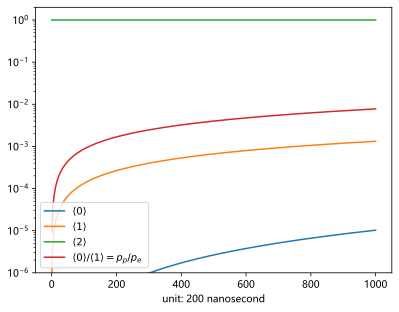

In [17]:
EJ = 4
EC = EJ/2.7
EL = EJ/45

qbt = gfIFQ(EJ = EJ,EC =EC,EL = EL)

temp_in_mK = 20
loss_tangent_ref = 1e-5
one_over_f_flux_noise_amplitude = 1e-6
scaling_factor = 1
tlist = np.linspace(0,int(1e3),1000)
scaling_factor = 200
result = qutip.mesolve(
    rho0=qutip.basis(qbt.truncated_dim, 2),
    H=qbt.diag_hamiltonian,
    tlist=tlist,
    c_ops=scaling_factor*qbt.get_c_ops(temp_in_mK,
                        loss_tangent_ref,
                        one_over_f_flux_noise_amplitude),
    e_ops = [qutip.ket2dm(qutip.basis(qbt.truncated_dim, i)) for i in range(5)],
    args=None,
    options=qutip.Options(store_states=True, nsteps=1200000, num_cpus=1),
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
)
plt.plot(tlist,result.expect[0],label=rf"$\langle{{0}}\rangle$")
plt.plot(tlist,result.expect[1],label=rf"$\langle{{1}}\rangle$")
plt.plot(tlist,result.expect[2],label=rf"$\langle{{2}}\rangle$")

plt.plot(tlist,result.expect[0]/result.expect[1],label=rf"$\langle{{0}}\rangle/\langle{{1}}\rangle = p_p/p_e$ ")
plt.legend()
plt.yscale('log')
plt.ylim(1e-6,2)
plt.xlabel(rf'unit: {scaling_factor} nanosecond')

 Total run time:   0.71s*] Elapsed 0.71s / Remaining 00:00:00:00


 /tmp/ipykernel_74659/1402745844.py: 29

Text(0.5, 0, 'unit: 10 nanosecond')

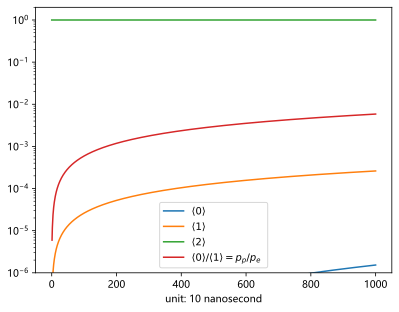

In [26]:
EJ = 4
EC = EJ/2
EL = EJ/30

qbt = gfIFQ(EJ = EJ,EC =EC,EL = EL)

temp_in_mK = 60
loss_tangent_ref = 1e-5
one_over_f_flux_noise_amplitude = 1e-6
scaling_factor = 1
tlist = np.linspace(0,int(1e3),1000)
scaling_factor = 10
result = qutip.mesolve(
    rho0=qutip.basis(qbt.truncated_dim, 2),
    H=qbt.diag_hamiltonian,
    tlist=tlist,
    c_ops=scaling_factor*qbt.get_c_ops(temp_in_mK,
                        loss_tangent_ref,
                        one_over_f_flux_noise_amplitude),
    e_ops = [qutip.ket2dm(qutip.basis(qbt.truncated_dim, i)) for i in range(5)],
    args=None,
    options=qutip.Options(store_states=True, nsteps=1200000, num_cpus=1),
    progress_bar = qutip.ui.progressbar.EnhancedTextProgressBar(),
)
plt.plot(tlist,result.expect[0],label=rf"$\langle{{0}}\rangle$")
plt.plot(tlist,result.expect[1],label=rf"$\langle{{1}}\rangle$")
plt.plot(tlist,result.expect[2],label=rf"$\langle{{2}}\rangle$")

plt.plot(tlist,result.expect[0]/result.expect[1],label=rf"$\langle{{0}}\rangle/\langle{{1}}\rangle = p_p/p_e$ ")
plt.legend()
plt.yscale('log')
plt.ylim(1e-6,2)
plt.xlabel(rf'unit: {scaling_factor} nanosecond')